Training Random Forest...
--- Random Forest Results ---
MAE: 2.3772 cents
R2 Score: 0.8626

Training XGBoost...
--- XGBoost Results ---
MAE: 2.6904 cents
R2 Score: 0.8615



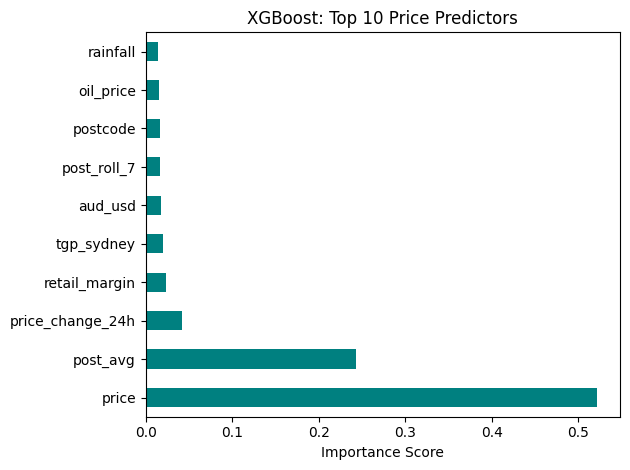

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('datasets/MODEL_READY_DATASET4.csv')

# 2. Chronological Split
# We do NOT shuffle fuel data because it is a time series
split_idx = int(len(df) * 0.8)
train, test = df.iloc[:split_idx], df.iloc[split_idx:]

X_train, y_train = train.drop(columns=['target_next_day_price']), train['target_next_day_price']
X_test, y_test = test.drop(columns=['target_next_day_price']), test['target_next_day_price']

# 3. XGBoost (Tuned for Stability)
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 4. Random Forest (Standard Baseline)
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1)

# 5. Training and Evaluation
models = [("Random Forest", rf), ("XGBoost", xgb)]

for name, model in models:
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"--- {name} Results ---")
    print(f"MAE: {mae:.4f} cents")
    print(f"R2 Score: {r2:.4f}\n")

# 6. Feature Importance Visualization
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("XGBoost: Top 10 Price Predictors")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

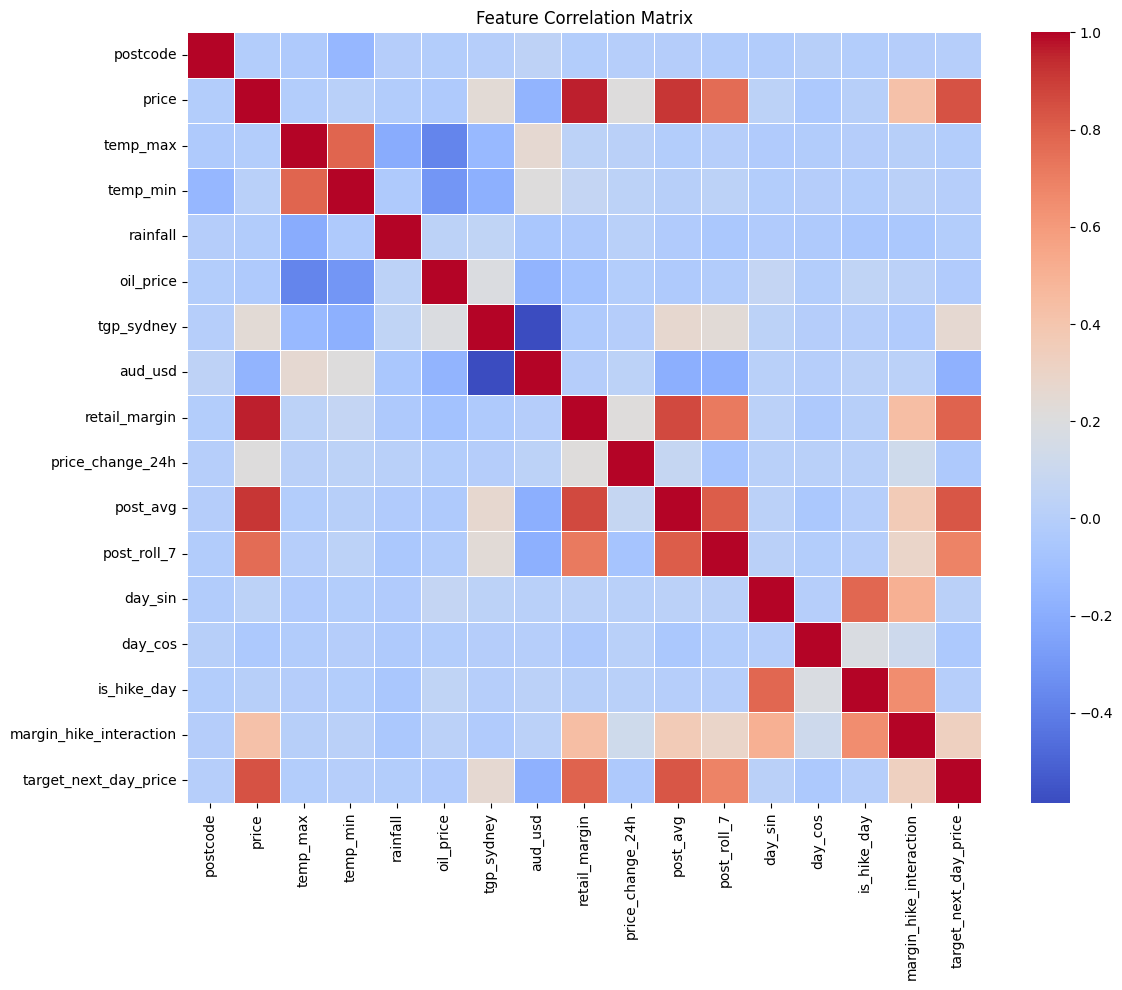

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [6]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue', s=2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (cents)')
plt.ylabel('Predicted Price (cents)')
plt.title(f'Actual vs. Predicted (R² = {r2_score(y_test, y_pred):.2f})')
plt.legend()
plt.show()

NameError: name 'y_pred' is not defined

<Figure size 800x800 with 0 Axes>